In [1]:
# ── 0. IMPORTS Y CONFIGURACIÓN ────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Asegurar que existen las carpetas de destino
os.makedirs('../figuras', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

In [2]:
# ── 1. CARGA Y PREPROCESAMIENTO EXACTO DE TUS DATOS ───────────────────────────
# Cargamos desde tu archivo original de Excel
df = pd.read_excel('../data/processed/datos.xlsx')
df['FECHA'] = pd.to_datetime(df['FECHA'])

# Filtrar solo ventas
df_ventas = df[df['TIPO_OPERACION'] == 'VENTA'].copy()

# Agrupamos usando la fecha truncada al primer día del mes (Timestamp)
df_ventas['PERIODO'] = df_ventas['FECHA'].dt.to_period('M').dt.to_timestamp()

# Agregar peso bruto mensual por familia
ventas_mensual = (
    df_ventas
    .groupby(['PERIODO', 'FAMILIA'])['PESO_BRUTO']
    .sum()
    .unstack('FAMILIA')
    .sort_index()
)

# ── FIX PARA EL ERROR DE FRECUENCIA ('MS') ────────────────────────────────────
# 1. Creamos un rango de fechas perfecto y continuo desde el inicio al fin del histórico
indice_perfecto = pd.date_range(
    start=ventas_mensual.index.min(),
    end=ventas_mensual.index.max(),
    freq='MS'
)

# 2. Reindexamos el DataFrame. Si faltaba algún mes intermedio en las ventas,
# se añade la fila vacía automáticamente en este paso.
ventas_mensual = ventas_mensual.reindex(indice_perfecto)

# 3. Ahora que el índice es continuo, rellenamos TODOS los NaNs con 0
ventas_mensual = ventas_mensual.fillna(0)
# ──────────────────────────────────────────────────────────────────────────────

# Extraemos la lista de familias dinámicamente y creamos colores homogéneos
FAMILIAS = ventas_mensual.columns.tolist()
cmap = plt.get_cmap('tab10')
COLORES = {familia: cmap(i % 10) for i, familia in enumerate(FAMILIAS)}

print(f'Período: {ventas_mensual.index[0].strftime("%Y-%m")} → {ventas_mensual.index[-1].strftime("%Y-%m")}')
print(f'Meses totales: {len(ventas_mensual)}')
print(f'Frecuencia asignada con éxito: {ventas_mensual.index.freqstr}')
print(f'Familias detectadas: {FAMILIAS}')

Período: 2010-12 → 2026-02
Meses totales: 183
Frecuencia asignada con éxito: MS
Familias detectadas: [106, 124, 233]


In [3]:
# ── 2. INGENIERÍA DE CARACTERÍSTICAS PARA REGRESIÓN REGULARIZADA ──────────────
def crear_caracteristicas_temporales(df_serie, columna_target):
    """
    Construye variables de retardo, medias móviles y estacionalidad determinista
    (one-hot de mes) sobre la serie en escala logarítmica. El uso de Ridge (L2)
    permite introducir un conjunto de variables potencialmente correlacionadas
    (varios lags + dummies mensuales) sin que el modelo sobreajuste, ya que la
    regularización penaliza la magnitud de los coeficientes.
    """
    df = df_serie[[columna_target]].copy()
    df.columns = ['target']

    # 1. Target en escala logarítmica (estabiliza la varianza y el efecto de outliers)
    df['target_log'] = np.log1p(df['target'])

    # 2. Retardos (lags) a corto y largo plazo
    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df['target_log'].shift(lag)

    # 3. Medias y desviaciones móviles (sobre valores ya pasados, shift(1) para evitar fuga)
    df['ma_3'] = df['target_log'].shift(1).rolling(window=3).mean()
    df['ma_6'] = df['target_log'].shift(1).rolling(window=6).mean()
    df['ma_12'] = df['target_log'].shift(1).rolling(window=12).mean()
    df['std_6'] = df['target_log'].shift(1).rolling(window=6).std()

    # 4. Variable de tendencia lineal pura (1, 2, 3... hasta N meses)
    df['tendencia'] = range(1, len(df) + 1)

    # 5. Componente estacional determinista (mes del año, codificado como dummies)
    df['mes'] = df.index.month
    df = pd.get_dummies(df, columns=['mes'], drop_first=True, dtype=int)

    # Eliminamos las filas con NaNs (los primeros 12 meses debido a los desplazamientos)
    df = df.dropna()
    return df

In [4]:
# ── 3. ENTRENAMIENTO: REGRESIÓN RIDGE (L2) CON TUNING DE ALPHA POR FAMILIA ────
resultados_baseline = {}

# Rejilla de valores de alpha a explorar mediante validación cruzada temporal
GRID_ALPHAS = {'alpha': [0.01, 0.1, 1.0, 3.0, 5.0, 10.0, 30.0, 50.0, 100.0]}

for familia in FAMILIAS:
    print(f"\n" + "=" * 60)
    print(f" REGRESIÓN RIDGE (L2) - FAMILIA {familia}")
    print("=" * 60)

    df_ml = crear_caracteristicas_temporales(ventas_mensual, familia)

    # Separamos las características del target
    X = df_ml.drop(columns=['target', 'target_log'])
    y_log = df_ml['target_log']
    y_real = df_ml['target']

    # Split Temporal: últimos 12 meses para TEST (sin mezcla aleatoria)
    meses_test = 12
    X_train, X_test = X.iloc[:-meses_test], X.iloc[-meses_test:]
    y_train_log, y_test_log = y_log.iloc[:-meses_test], y_log.iloc[-meses_test:]
    y_train_real, y_test_real = y_real.iloc[:-meses_test], y_real.iloc[-meses_test:]

    print(f"Registros en Entrenamiento (Train): {len(X_train)} meses")
    print(f"Registros en Validación (Test):      {len(X_test)} meses")

    # Estandarización de variables (imprescindible para Ridge), ajustada SOLO con train
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Validación cruzada temporal (walk-forward) para seleccionar alpha
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(
        estimator=Ridge(random_state=42),
        param_grid=GRID_ALPHAS,
        scoring='neg_root_mean_squared_error',
        cv=tscv,
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train_log)

    modelo_ridge = grid.best_estimator_
    print(f"  Mejor alpha (CV temporal): {grid.best_params_['alpha']}")

    # Predicción sobre el conjunto de test (en escala log) y vuelta a la escala original
    preds_log = modelo_ridge.predict(X_test_scaled)
    preds_test = np.expm1(preds_log)
    preds_test = np.clip(preds_test, a_min=0, a_max=None)

    # Cálculo de métricas sobre los valores REALES (en kg)
    rmse = root_mean_squared_error(y_test_real, preds_test)
    mae = mean_absolute_error(y_test_real, preds_test)
    mape = np.mean(np.abs((y_test_real - preds_test) / (y_test_real + 1e-5))) * 100
    smape = np.mean(
        2 * np.abs(y_test_real - preds_test) / (np.abs(y_test_real) + np.abs(preds_test) + 1e-5)
    ) * 100

    print(f"\n📊 Resultados Reales en Test con Ridge (Familia {familia}):")
    print(f"  -> RMSE:  {rmse:,.2f} kg")
    print(f"  -> MAE:   {mae:,.2f} kg")
    print(f"  -> MAPE:  {mape:.2f}%")
    print(f"  -> SMAPE: {smape:.2f}%")

    resultados_baseline[familia] = {
        'modelo': modelo_ridge,
        'scaler': scaler,
        'best_alpha': grid.best_params_['alpha'],
        'y_test_real': y_test_real,
        'preds_test': preds_test,
        'metrics': {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'SMAPE': smape}
    }


 REGRESIÓN RIDGE (L2) - FAMILIA 106
Registros en Entrenamiento (Train): 159 meses
Registros en Validación (Test):      12 meses
  Mejor alpha (CV temporal): 10.0

📊 Resultados Reales en Test con Ridge (Familia 106):
  -> RMSE:  27,891.85 kg
  -> MAE:   14,593.01 kg
  -> MAPE:  442.94%
  -> SMAPE: 106.26%

 REGRESIÓN RIDGE (L2) - FAMILIA 124
Registros en Entrenamiento (Train): 159 meses
Registros en Validación (Test):      12 meses
  Mejor alpha (CV temporal): 30.0

📊 Resultados Reales en Test con Ridge (Familia 124):
  -> RMSE:  55,089.10 kg
  -> MAE:   47,811.43 kg
  -> MAPE:  86.10%
  -> SMAPE: 70.05%

 REGRESIÓN RIDGE (L2) - FAMILIA 233
Registros en Entrenamiento (Train): 159 meses
Registros en Validación (Test):      12 meses
  Mejor alpha (CV temporal): 100.0

📊 Resultados Reales en Test con Ridge (Familia 233):
  -> RMSE:  22,146.72 kg
  -> MAE:   18,556.63 kg
  -> MAPE:  60.34%
  -> SMAPE: 70.69%


In [7]:
# ── 4. EXPORTACIÓN DE MÉTRICAS ────────────────────────────────────────────────
df_metrics_regression = pd.DataFrame({f: resultados_baseline[f]['metrics'] for f in FAMILIAS}).T
ruta_metricas = '../data/processed/03_metricas_regression.csv'
df_metrics_regression.to_csv(ruta_metricas, index_label='Familia')

print("\n" + "=" * 60)
print(" RESUMEN FINAL EXPORTADO CORRECTAMENTE")
print("=" * 60)
print(df_metrics_regression)
print(f"\nAlphas óptimos por familia: " +
      ", ".join(f"{f}={resultados_baseline[f]['best_alpha']}" for f in FAMILIAS))
print(f"\nArchivo de métricas consolidado en: {ruta_metricas}")


 RESUMEN FINAL EXPORTADO CORRECTAMENTE
             RMSE           MAE        MAPE       SMAPE
106  27891.847578  14593.006676  442.940309  106.264543
124  55089.095181  47811.433861   86.099441   70.047995
233  22146.723876  18556.626744   60.340464   70.694043

Alphas óptimos por familia: 106=10.0, 124=30.0, 233=100.0

Archivo de métricas consolidado en: ../data/processed/03_metricas_regression.csv


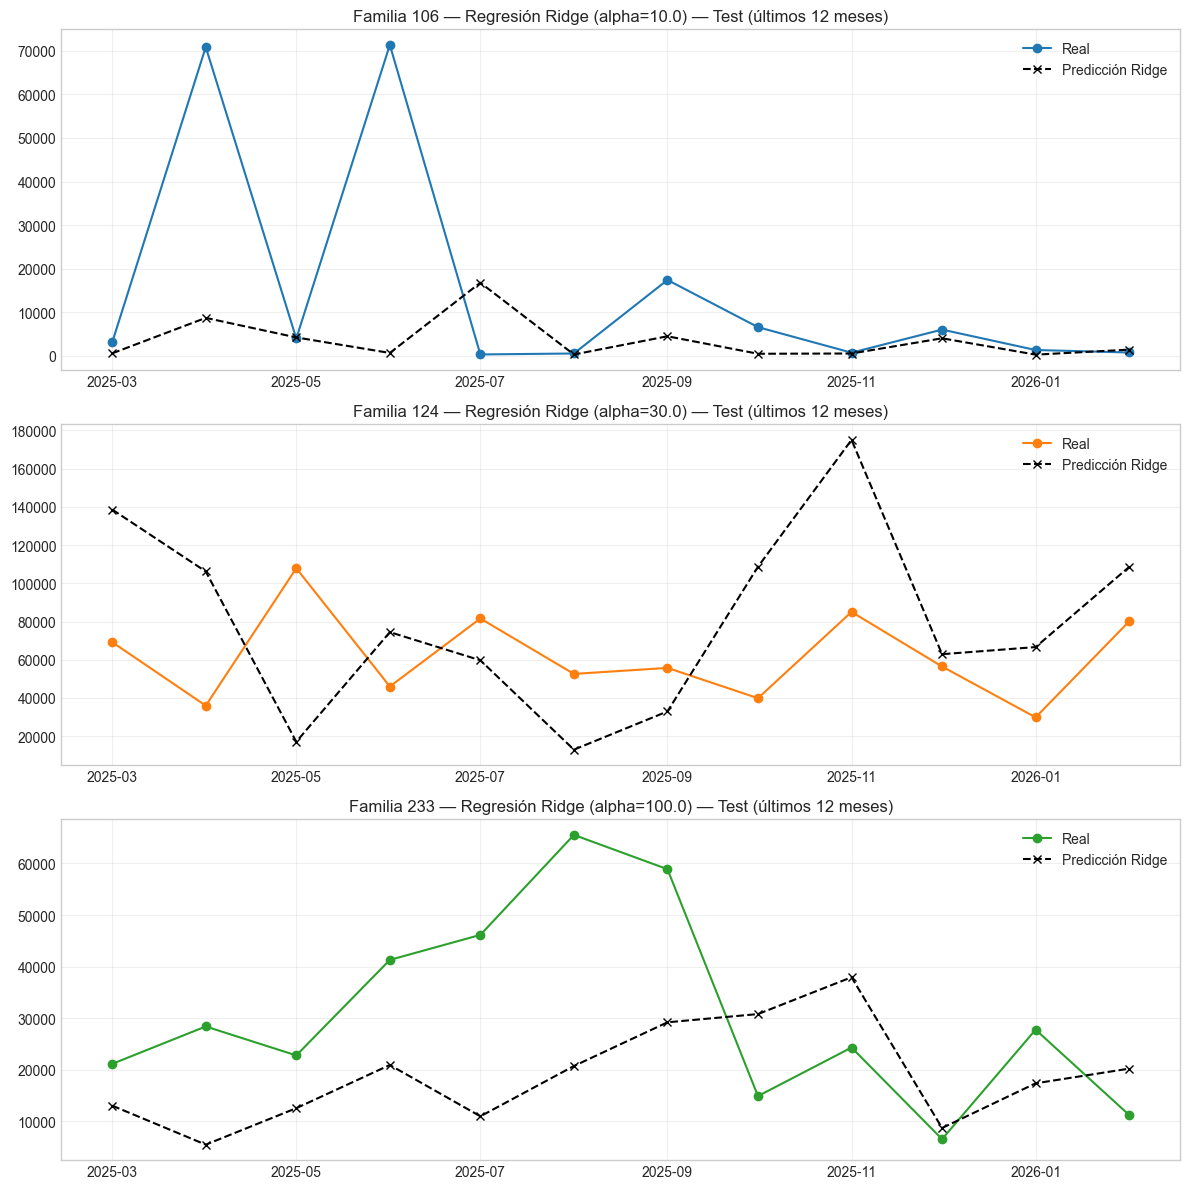

Figura guardada: ../figuras/03_prediccion_regression.pdf


In [9]:
# ── 5. VISUALIZACIÓN: REAL VS. PREDICHO POR FAMILIA (TEST) ────────────────────
fig, axes = plt.subplots(len(FAMILIAS), 1, figsize=(12, 4 * len(FAMILIAS)), sharex=False)
if len(FAMILIAS) == 1:
    axes = [axes]

for ax, familia in zip(axes, FAMILIAS):
    res = resultados_baseline[familia]
    ax.plot(res['y_test_real'].index, res['y_test_real'].values, label='Real', marker='o', color=COLORES[familia])
    ax.plot(res['y_test_real'].index, res['preds_test'], label='Predicción Ridge', marker='x', linestyle='--', color='black')
    ax.set_title(f'Familia {familia} — Regresión Ridge (alpha={res["best_alpha"]}) — Test (últimos 12 meses)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figuras/03_prediccion_regression.pdf')
plt.show()
print("Figura guardada: ../figuras/03_prediccion_regression.pdf")